## Architecture overview

```text
data.py
  load_lensing_dataset_index(...)
  build_standardized_image_datasets(...)
  build_augmented_standardized_image_datasets(...)

classical.py
  DeepLenseResidualClassifier(...)
  DeepLenseWideResidualClassifier(...)

training.py
  train_torch_classifier(...)
  predict_probabilities(...)

evals.py
  compute_multiclass_auc(...)
  one_vs_rest_roc_curves(...)
  plot_roc_curves(...)

experiments.py
  run_common_test(...) -> CommonTestResult
```

In [1]:
from __future__ import annotations

import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from torch import nn

from dark_matter_lensing_qml import (
    CommonTestConfig,
    DataConfig,
    DeepLenseResidualClassifier,
    build_augmented_standardized_image_datasets,
    build_image_datasets,
    build_standardized_image_datasets,
    count_samples_per_class,
    load_lensing_dataset_index,
    read_lensing_sample,
    run_common_test,
)
from dark_matter_lensing_qml.classical import DeepLenseWideResidualClassifier
from dark_matter_lensing_qml.evals import compute_multiclass_auc, one_vs_rest_roc_curves, plot_roc_curves
from dark_matter_lensing_qml.training import build_torch_dataloader

In [2]:
print("torch.__version__:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.cuda.device_count():", torch.cuda.device_count())
if torch.cuda.is_available():
    print("torch.cuda.get_device_name(0):", torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("selected device:", device)

torch.__version__: 2.11.0+cu130
torch.version.cuda: 13.0
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
torch.cuda.get_device_name(0): NVIDIA GeForce RTX 4080 Laptop GPU
selected device: cuda


## Preparing dataset

The provided dataset is currently in a `80:20` folder split (`30000 / 7500`). To achieve `90:10` split expected in the task, we rebuild a deterministic split from the full sample pool. We also do lazy loading through the PyTorch dataset wrapper.

In [3]:
data_config = DataConfig(
    normalize=True,
    loader_workers=0,
)

folder_train_count = len(list((data_config.dataset_root / "train").glob("*/*.npy")))
folder_val_count = len(list((data_config.dataset_root / "val").glob("*/*.npy")))
print("folder train count:", folder_train_count)
print("folder val count:", folder_val_count)
print("folder split ratio:", f"{folder_train_count}:{folder_val_count}")

dataset_index = load_lensing_dataset_index(
    data_config.dataset_root,
    class_names=list(data_config.class_names),
    validation_fraction=data_config.validation_fraction,
    split_seed=data_config.split_seed,
)
print("rebuilt train counts:", count_samples_per_class(dataset_index.train_split))
print("rebuilt validation counts:", count_samples_per_class(dataset_index.validation_split))
print("class names:", dataset_index.class_names)


folder train count: 30000
folder val count: 7500
folder split ratio: 30000:7500


rebuilt train counts: {'no': 11250, 'sphere': 11250, 'vort': 11250}
rebuilt validation counts: {'no': 1250, 'sphere': 1250, 'vort': 1250}
class names: ['no', 'sphere', 'vort']


## General appearance of classes

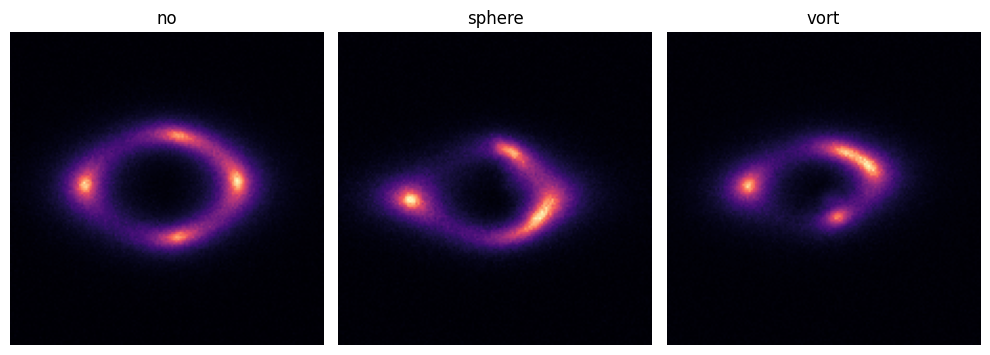

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for axis, class_name in zip(axes, dataset_index.class_names):
    class_id = dataset_index.class_names.index(class_name)
    first_index = int(np.where(dataset_index.train_split.labels == class_id)[0][0])
    sample_path = dataset_index.train_split.paths[first_index]
    sample = read_lensing_sample(sample_path)

    axis.imshow(sample[0], cmap="magma")
    axis.set_title(class_name)
    axis.axis("off")

plt.tight_layout()

## Small experiments
Original simple CNN I realized had a near-random choice levels of AUC, requiring experimentation to find a good architecture and hyperparameters. While smaller models outperform larger ones in my tests, perhaps larger datasets could saturate them.

### Final comparsion table

| candidate                                                                 | macro AUC | micro AUC | notes                                      |
|---------------------------------------------------------------------------| ---: | ---: |--------------------------------------------|
| small CNN, `64x64`                                                        | 0.5039 | 0.5013 | collapses to one class                     |
| residual CNN, `64x64`                                                     | 0.5110 | 0.5082 | better than the small baseline, still weak |
| residual CNN, `32x32`, standardized                                       | 0.5777 | 0.5810 | first real recovery                        |
| residual CNN, `32x32`, standardized + augmentation, seed 0                | 0.6415 | 0.6500 | strong jump from the non-augmented run     |
| residual CNN, `32x32`, standardized + augmentation, seed 1                | 0.6480 | 0.6645 | same quality band                          |
| residual CNN, `32x32`, standardized + augmentation, seed 2                | 0.6432 | 0.6586 | same quality band                          |
| residual CNN, `32x32`, standardized + augmentation, mean over seeds 0/1/2 | 0.6442 | n/a | selected final path                        |
| wide residual CNN, `32x32`, standardized + augmentation                   | 0.6376 | 0.6480 | more capacity, not better                  |

Findings after the experiments:
- the tested `64x64` setup was worse than the tested `32x32` setup
- train-set made a big impact
- safe augmentation also made a big impact
- a wider residual model did not provide enough to replace the simpler winner (but perhaps larger datasets could saturate richer models)

### Interpretation of findings
- large resolution (`64x64`) might be redundant when we target large scale morphology for substructure classification, but it makes optimization much harder
- at `32x32`, the image is still large enough to preserve arc shape, asymmetry, and local distortions
- the input is small enough that the model can train cleanly on the available data
- standardization reduces intensity-scale drift so the network can focus more on structure than on raw amplitude
- safe augmentation (rotations, flips, and mild shifts) encourage the network to treat the substructure signal as a morphological pattern rather than as a fixed pixel layout.
- the most important step is to preserve and stabilize the right image features

In [5]:
class TinyLensBaseline(nn.Module):
    def __init__(self, n_lensing_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, n_lensing_classes),
        )

    def forward(self, images):
        return self.classifier(self.features(images))


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def predict_probs(model, dataset, batch_size, loader_workers, device):
    use_cuda = device.startswith("cuda")
    loader = build_torch_dataloader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        loader_workers=loader_workers,
    )
    model.to(device)
    model.eval()

    parts = []
    with torch.no_grad():
        for batch_images, _ in loader:
            batch_images = batch_images.to(device, non_blocking=True)
            if use_cuda:
                batch_images = batch_images.to(memory_format=torch.channels_last)
            logits = model(batch_images)
            probs = torch.softmax(logits, dim=1)
            parts.append(probs.cpu().numpy().astype(np.float32, copy=False))

    return np.concatenate(parts, axis=0).astype(np.float32, copy=False)


def train_image_model(
        model,
        train_dataset,
        validation_dataset,
        batch_size,
        learning_rate,
        weight_decay,
        epochs,
        loader_workers,
        device,
        seed,
        use_cosine_schedule=False,
):
    set_seed(seed)
    use_cuda = device.startswith("cuda")
    loader = build_torch_dataloader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        loader_workers=loader_workers,
    )
    model = model.to(device)
    if use_cuda:
        model = model.to(memory_format=torch.channels_last)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = None
    if use_cosine_schedule:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=use_cuda)
    criterion = nn.CrossEntropyLoss()

    best_score = float("-inf")
    best_state = None
    best_metrics = None
    best_probabilities = None
    mean_losses = []

    for _ in range(epochs):
        model.train()
        loss_sum = 0.0
        n_batches = 0

        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)
            if use_cuda:
                batch_images = batch_images.to(memory_format=torch.channels_last)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_cuda):
                logits = model(batch_images)
                loss = criterion(logits, batch_labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_sum += float(loss.detach().cpu().item())
            n_batches += 1

        mean_losses.append(loss_sum / max(n_batches, 1))
        probabilities = predict_probs(
            model,
            validation_dataset,
            batch_size=batch_size,
            loader_workers=loader_workers,
            device=device,
        )
        metrics = compute_multiclass_auc(
            validation_dataset.split_index.labels,
            probabilities,
            n_lensing_classes=len(validation_dataset.split_index.class_names),
        )
        if metrics.macro_auc > best_score:
            best_score = metrics.macro_auc
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = metrics
            best_probabilities = probabilities
        if scheduler is not None:
            scheduler.step()

    model.load_state_dict(best_state)
    return model, mean_losses, best_metrics, best_probabilities


def compare_common_models(dataset_index, data_config, device="cpu", seed=0):
    n_lensing_classes = len(dataset_index.class_names)
    runs = [
        (
            "tiny_64",
            lambda: TinyLensBaseline(n_lensing_classes),
            lambda: build_image_datasets(dataset_index, normalize=data_config.normalize, resized_image_size=64),
            1e-3,
            1e-4,
            6,
            32,
            False,
        ),
        (
            "residual_64",
            lambda: DeepLenseResidualClassifier(n_lensing_classes=n_lensing_classes),
            lambda: build_image_datasets(dataset_index, normalize=data_config.normalize, resized_image_size=64),
            1e-3,
            1e-4,
            6,
            32,
            False,
        ),
        (
            "residual_32_std",
            lambda: DeepLenseResidualClassifier(n_lensing_classes=n_lensing_classes),
            lambda: build_standardized_image_datasets(dataset_index, normalize=data_config.normalize, resized_image_size=32),
            3e-4,
            1e-4,
            10,
            32,
            False,
        ),
        (
            "residual_32_std_aug",
            lambda: DeepLenseResidualClassifier(n_lensing_classes=n_lensing_classes),
            lambda: build_augmented_standardized_image_datasets(dataset_index, normalize=data_config.normalize, resized_image_size=32),
            2e-4,
            1e-4,
            12,
            32,
            True,
        ),
        (
            "wide_residual_32_std_aug",
            lambda: DeepLenseWideResidualClassifier(n_lensing_classes=n_lensing_classes),
            lambda: build_augmented_standardized_image_datasets(dataset_index, normalize=data_config.normalize, resized_image_size=32),
            2e-4,
            1e-4,
            12,
            32,
            True,
        ),
    ]

    rows = []
    for name, build_model, build_datasets, lr, weight_decay, epochs, batch_size, use_cosine_schedule in runs:
        train_dataset, validation_dataset = build_datasets()
        _, mean_losses, metrics, _ = train_image_model(
            build_model(),
            train_dataset,
            validation_dataset,
            batch_size,
            lr,
            weight_decay,
            epochs,
            data_config.loader_workers,
            device,
            seed,
            use_cosine_schedule,
        )
        rows.append(
            {
                "candidate": name,
                "macro_auc": float(metrics.macro_auc),
                "micro_auc": float(metrics.micro_auc),
                "mean_losses": mean_losses,
            }
        )

    return rows


In [6]:
# Takes 5min on GPU, 10-20 on CPU
common_comparison_rows = compare_common_models(dataset_index, data_config, device=device, seed=0)
common_comparison_rows

[{'candidate': 'tiny_64',
  'macro_auc': 0.5159117866666666,
  'micro_auc': 0.5053039288888889,
  'mean_losses': [1.0988318696406216,
   1.0987442509257963,
   1.0986880597345072,
   1.0987733774275577,
   1.0987127866790194,
   1.0987068198868448]},
 {'candidate': 'residual_64',
  'macro_auc': 0.5074743466666667,
  'micro_auc': 0.5036745066666667,
  'mean_losses': [1.1010671107124943,
   1.0998855728673709,
   1.0992975263234,
   1.099588750323978,
   1.0991799055117566,
   1.0989201668879431]},
 {'candidate': 'residual_32_std',
  'macro_auc': 0.5719651199999999,
  'micro_auc': 0.5752470577777777,
  'mean_losses': [1.1016842567525205,
   1.0970151797290097,
   1.08693483147011,
   1.0575311164720365,
   1.0028421407627268,
   0.9218010804099495,
   0.813350398619593,
   0.6835439463079823,
   0.550024295926659,
   0.429171715217744]},
 {'candidate': 'residual_32_std_aug',
  'macro_auc': 0.6416573866666667,
  'micro_auc': 0.6524963022222221,
  'mean_losses': [1.1017672090168813,
   1.0

# Train the selected version
The `run_common_test(...)` trains the version selected in experiments,
- `32x32` images
- lazy loading from the train/validation split
- train-set standardization
- safe train-only augmentation
- residual CNN backbone
- validation macro AUC-based model selection

In [7]:
common_test_config = CommonTestConfig()

common_result = run_common_test(
    dataset_index,
    data_config=data_config,
    test_config=common_test_config,
    device=device,
)


training: epoch=1/12 mean_loss=1.1020 macro_auc=0.5115


training: epoch=2/12 mean_loss=1.0982 macro_auc=0.5186


training: epoch=3/12 mean_loss=1.0950 macro_auc=0.5410


training: epoch=4/12 mean_loss=1.0843 macro_auc=0.5605


training: epoch=5/12 mean_loss=1.0675 macro_auc=0.5960


...

training: epoch=8/12 mean_loss=1.0264 macro_auc=0.6265


training: epoch=9/12 mean_loss=1.0139 macro_auc=0.6332


training: epoch=10/12 mean_loss=1.0058 macro_auc=0.6355


training: epoch=11/12 mean_loss=0.9994 macro_auc=0.6418


training: epoch=12/12 mean_loss=0.9961 macro_auc=0.6436


## Training loss and validation

In [8]:
print("mean_losses:", common_result.mean_losses)
print("macro_auc:", common_result.metrics.macro_auc)
print("micro_auc:", common_result.metrics.micro_auc)
print("per_class_auc:", common_result.metrics.per_class_auc)
print("confusion_matrix:", common_result.metrics.confusion)

mean_losses: [1.101993444067607, 1.0982132608856634, 1.0950013278219937, 1.0842636492580033, 1.0674568273444875, 1.0521311813056187, 1.037515310427589, 1.0263719016341801, 1.013893310379643, 1.0058288668004258, 0.9993905080438226, 0.9961446925927112]
macro_auc: 0.6435944
micro_auc: 0.6588663644444445
per_class_auc: (0.6704768, 0.55614832, 0.70415808)
confusion_matrix: [[886 142 222]
 [660 194 396]
 [477  90 683]]


## ROC curves

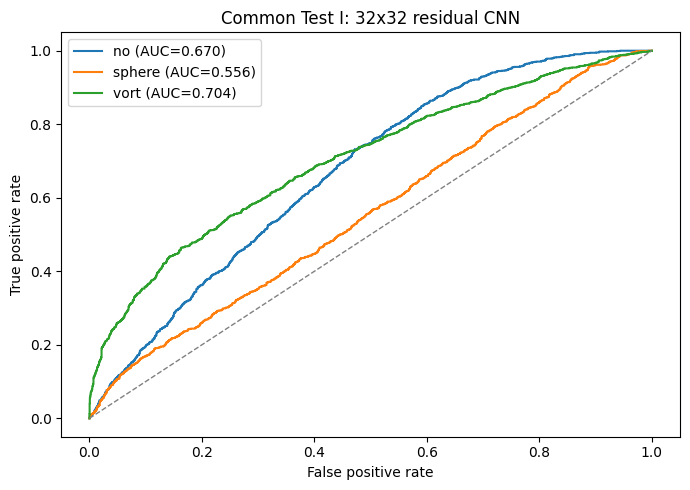

In [9]:
roc_curves = one_vs_rest_roc_curves(
    common_result.validation_labels,
    common_result.predicted_probabilities,
    n_lensing_classes=len(common_result.class_names),
)

plot_roc_curves(
    roc_curves,
    class_names=common_result.class_names,
    title="Common Test I: 32x32 residual CNN",
)
